### 目的：验证模型在预测免疫治疗反应的性能

In [ ]:
### 环境配置

In [1]:
set.seed(42)

target_dir = "~/TCGA-LUAD/"
rna_meth_dir = paste0(target_dir, "result/preprocess/")
subtype_dir = paste0(target_dir, "result/Cox_all_subtype/")
riskmodel_dir = paste0(target_dir, "result/split_degs_riskmodel/")
result_dir = paste0(target_dir, "result/immunotherapy/")
if (!file.exists(result_dir)){
    dir.create(result_dir, recursive = TRUE)
}
print(result_dir)

[1] "~/TCGA-LUAD/result/immunotherapy/"


### 免疫治疗反应队列
*  the urothelial carcinoma immunotherapy cohort (IMvigor210): http://research-pub.gene.com/IMvigor210CoreBiologies/packageVersions/IMvigor210CoreBiologies_1.0.1.tar.gz
*  the melanoma immunotherapy cohort (GSE78220)

In [2]:
# 加载训练集参数（均值，标准差，cutoff）
train_params <- read.table(paste0(riskmodel_dir, "train.mean.sd.surv_cutpoint.cutoff.imp_df.txt"), sep="\t", header=TRUE)

# 提取模型基因与系数
model_features_coef <- read.table(paste0(riskmodel_dir, "train_lasso_feature_coef.txt"), sep="\t", header=TRUE)

# 提取模型基因
model_genes <- gsub("_rna", "", model_features_coef$Feature)

#### TIDE——TIDEpy

In [4]:
# 准备输入文件
rna_final <- read.table(paste0(subtype_dir,"rna_final.txt"), sep="\t", check.names = F)
train_risk_df <- read.table(paste0(riskmodel_dir,"train_risk_df.txt"), sep="\t", check.names = F)
train_TIDE <- rna_final[, match(train_risk_df$sample_id, colnames(rna_final))]
write.table(train_TIDE, paste0(result_dir, "data/train_TIDE_input.txt"), sep = "\t", quote = FALSE, row.names = TRUE, col.names = TRUE)

In [ ]:
# tidepy计算TIDE得分
import pandas as pd
from tidepy.pred import TIDE
df = pd.read_csv(paste0(result_dir, "data/train_TIDE_input.txt"),sep='\t',index_col=0)
result = TIDE(df,cancer='Others',pretreat=False,vthres=0.)
result.to_csv(paste0(result_dir, "train_TIDE.result.txt"), sep="\t")

Warning message:
"package 'ggpubr' was built under R version 4.5.3"
Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"


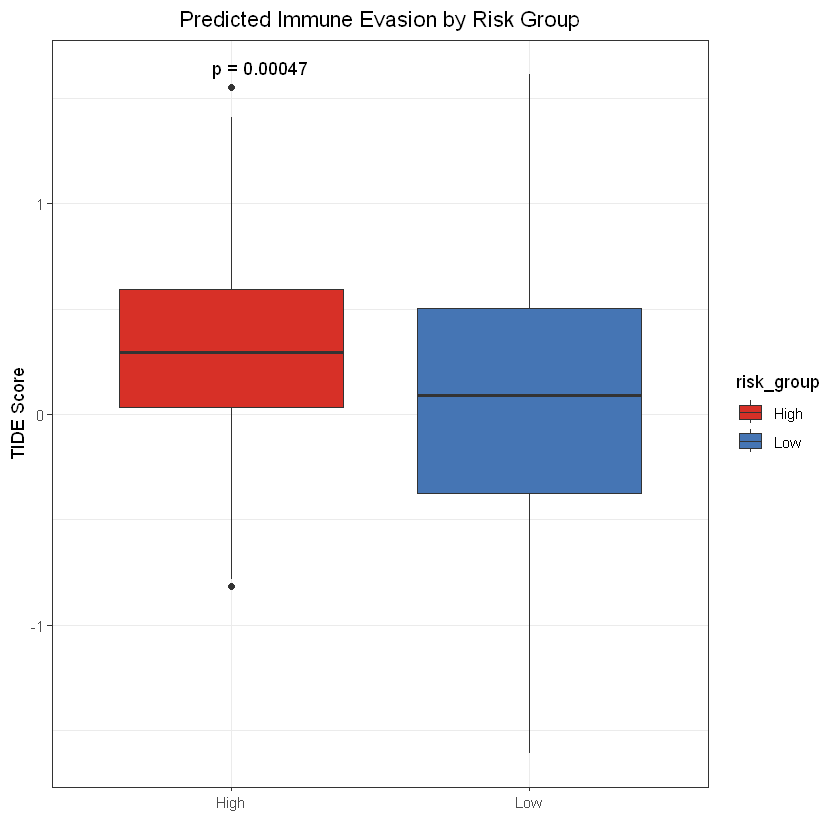

In [5]:
# 读取TIDE预测文件
tide_res <- read.csv(paste0(result_dir, "train_TIDE.result.txt"), sep="\t", header = TRUE, row.names = 1)

# 合并临床与风险分组数据
tide_res$sample_id <- rownames(tide_res)
merged_data <- merge(train_risk_df, tide_res, by = "sample_id")

# 比较高低风险组 TIDE 评分差异
library(ggpubr)
tide_p <- ggplot(merged_data, aes(x = risk_group, y = TIDE, fill = risk_group)) +
  geom_boxplot() +
  stat_compare_means(method = "wilcox.test", label = "p.format") +
  scale_fill_manual(values = c("High" = "#D73027", "Low" = "#4575B4")) +
  labs(x="", y = "TIDE Score", title = "Predicted Immune Evasion by Risk Group") +
  theme_bw() +
  theme(plot.title = element_text(hjust=0.5))
print(tide_p)
ggsave(paste0(result_dir, "Train_TIDE_predict_Immune_Evasion.boxplot.pdf"), tide_p, width = 10, height = 8, dpi=300)

#### GSE78220

In [6]:
library(survival)
library(survminer)
library(ggplot2)
library(ggpubr)
library(dplyr)

# GSE78220 FPKM表达矩阵 & clinical information
fpkm_exp <- read.table(paste0(result_dir, "data/GSE78220_PatientFPKM.txt"), sep="\t", header=T, row.names=1)
clin_info <- read.table(paste0(result_dir, "data/GSE78220_clinical_info.txt"), sep="\t", header=T)

# 仅保留基线样本, 剔除 OnTx 等其他时间点
baseline_idx <- grep("baseline", colnames(fpkm_exp), ignore.case = TRUE)
if(length(baseline_idx) == 0) stop("Not found baseline samples, please check the sample name!")
fpkm_baseline <- fpkm_exp[, baseline_idx, drop = FALSE]
colnames(fpkm_baseline) <- gsub("/.baseline.*", "", colnames(fpkm_baseline), ignore.case = TRUE)

# 同一患者多个基线样本 → 取均值
fpkm_baseline <- fpkm_baseline %>% mutate(Pt27 = rowMeans(cbind(Pt27A, Pt27B))) %>% select(-Pt27A, -Pt27B) 
print(head(fpkm_baseline))

Warning message:
"package 'survival' was built under R version 4.5.3"
Warning message:
"package 'survminer' was built under R version 4.5.3"

Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




                  Pt1          Pt2        Pt4         Pt5          Pt6
A1BG       8.02538000 317.59400000  5.7472950  6.85957000   1.56346500
A1BG-AS1   0.67750300  28.37820000  0.4713935  0.34762300   0.20176000
A1CF       0.00000000  18.10940000  0.0000000  0.00000000   0.01127618
A2M      185.30400000 455.16000000 81.0082000 41.41065000 136.16350000
A2M-AS1    0.36353100   2.86445500  0.2012845  0.04082075   0.41742300
A2ML1      0.01413385   0.01269185  0.0225053  0.00383668   0.00000000
               Pt7          Pt8          Pt9         Pt10         Pt12
A1BG     21.565850  11.37055000 8.156810e+00   4.34675000   6.50871500
A1BG-AS1  8.926245   3.85312500 2.539610e+00   1.91435000   4.79793000
A1CF      0.000000   0.00326287 1.398225e-03   0.00000000   0.00000000
A2M      44.669350 119.01750000 2.326750e+02 501.69700000 530.23750000
A2M-AS1   1.039475   3.12602500 4.216800e+00   1.48984500   1.86852000
A2ML1     0.010840   0.04466300 4.475855e-01   0.03080075   0.00737025
      

In [7]:
# Log2 转换
fpkm_baseline_log2 <- log2(fpkm_baseline + 1)

# 检查基因是否存在
missing_genes <- setdiff(model_genes, rownames(fpkm_baseline))
if(length(missing_genes) > 0) {
  cat("警告：以下基因在 GSE78220 中缺失，将设为 0 表达：", paste(missing_genes, collapse = ", "), "\n")
  for(g in missing_genes) {
    fpkm_baseline_log2[g, ] <- 0
  }
}

# 按模型基因顺序提取子集并Z-score 标准化
fpkm_baseline_sub <- fpkm_baseline_log2[model_genes, , drop = FALSE]
fpkm_baseline_scaled <- (fpkm_baseline_sub - train_params[model_genes ,"train_mean"]) / train_params[model_genes ,"train_sd"]
fpkm_baseline_scaled

# 计算风险评分
riskscore <- colSums(fpkm_baseline_scaled * model_features_coef$Coef)
print(head(riskscore))

# 根据训练集 cutoff 分组
risk_group <- ifelse(riskscore > unique(train_params[,"train_cutoff"]), "High", "Low")

risk_df <- data.frame(
  `Patient ID` = names(riskscore),
  RiskScore  = as.numeric(riskscore),
  RiskGroup  = risk_group,
  stringsAsFactors = FALSE,
  row.names = NULL,
  check.names = FALSE
)

# 合并临床信息 疗效评估：'Progressive Disease(PD)''Partial Response(PR)''Complete Response(CR)' 'Stable Disease(SD)'
clin_info <- read.table(paste0(result_dir, "data/GSE78220_clinical_info.txt"), sep="\t", header=T, check.names = FALSE)
clinical_gse78220 <- clin_info[, c("Patient ID", "irRECIST", "Overall Survival", "Vital Status")]

unique(clin_info$irRECIST)

clinical_gse78220 <- clinical_gse78220 %>% 
  mutate(
      Response = case_when(
          # response
          irRECIST %in% c("Complete Response", "Partial Response") ~ "Responder",
          # no response
          irRECIST == "Progressive Disease" ~ "Non-responder",
          TRUE ~ NA_character_
      ),
      OS_event = ifelse(`Vital Status` == "Dead", 1, 0), # dead:1 alive:0
      Response_4cat = case_when(
          irRECIST == "Complete Response" ~ "CR",
          irRECIST == "Partial Response" ~ "PR",
          irRECIST == "Progressive Disease" ~ "PD",
          TRUE ~ NA_character_
      )
  )

clinical_risk_df <- merge(clinical_gse78220, risk_df, by = "Patient ID")
print(head(clinical_risk_df))

write.table(clinical_risk_df, paste0(result_dir, "gse78220_clinical_risk_df.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

,Pt1,Pt2,Pt4,Pt5,Pt6,Pt7,Pt8,Pt9,Pt10,Pt12,⋯,Pt23,Pt25,Pt28,Pt29,Pt31,Pt32,Pt35,Pt37,Pt38,Pt27
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ANLN,-3.9404509,-5.13290736,-3.8196386,-3.9284132,-4.50830249,-2.8633011,-3.8775857,-3.9162610,-2.9205488,-3.0299857,⋯,-3.5123180,-4.4066261,-4.2071768,-3.4157634,-4.0056719,-4.7052037,-3.5872145,-4.8655679,-4.8969832,-3.9976621
GPD1L,-6.1864949,-7.07901310,-6.0112495,-5.9031599,-6.73151662,-7.2589217,-7.2142433,-6.4175885,-6.2078310,-7.4912764,⋯,-8.5672596,-8.7475092,-8.7951010,-6.8901127,-8.7892144,-9.3671419,-8.2768659,-7.0201475,-7.8153373,-6.7348341
CAV3,-0.7144679,-0.71446787,-0.7144679,-0.7144679,-0.71446787,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,⋯,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.7144679
ERO1L,-6.4612764,-6.32168298,-7.3320515,-5.6430934,-5.11392066,-6.9149184,-7.4781731,-7.4185679,-5.0646868,-6.9989442,⋯,-5.9053322,-8.4051258,-5.9989178,-7.0423129,-7.5512934,-8.2116235,-7.0119165,-7.2350420,-7.9223686,-7.1038472
GNG7,-2.2403690,-2.00123175,-2.5312341,-2.3460337,-2.90307888,-0.9235478,-1.2922783,-2.6638035,-3.6072983,-3.8160776,⋯,-4.8130242,-2.3954067,-5.1162322,-2.3738492,-5.0865277,-4.2336312,-2.4978636,-1.3916613,-1.7407041,-1.2886247
HMGCLL1,-2.3174846,-2.27821477,-2.3751987,-2.3751987,-2.32853392,-2.3751987,-2.3751987,-2.2526421,-2.3751987,-2.3751987,⋯,-2.3751987,-2.3569885,-2.3162504,-2.0800361,-2.3751987,-2.0432035,-2.3751987,-2.3751987,-2.0578977,-2.3451201
IRX5,-2.6562348,-3.54228664,-3.1964867,-2.3548696,-2.47266610,-2.0016041,-3.4026789,-2.0035376,-3.2422779,-3.4413375,⋯,-2.7516270,-2.5976120,-2.5997233,-3.0901439,-2.8042245,-2.4973002,-2.5459119,-3.1965084,-3.4298659,-1.7270891
ABCC2,-0.9852486,-0.04589207,-1.5684646,-0.2790413,-0.04301226,-0.6525452,-1.6343287,-1.6076935,-1.6289570,-1.2138421,⋯,-1.3210123,-1.3261821,-1.3748960,-1.4947071,-0.9380090,-1.6383870,-0.5563670,-0.1318512,-1.3504784,-0.7270904


       Pt1        Pt2        Pt4        Pt5        Pt6        Pt7 
0.04089396 0.10157700 0.06761292 0.04537426 0.04831452 0.10894519 


[1] "Progressive Disease" "Partial Response"    "Complete Response"

  Patient ID            irRECIST Overall Survival Vital Status      Response
1        Pt1 Progressive Disease              607         Dead Non-responder
2       Pt10 Progressive Disease              387        Alive Non-responder
3       Pt12 Progressive Disease              327         Dead Non-responder
4       Pt13   Complete Response              917        Alive     Responder
5       Pt14 Progressive Disease               54        Alive Non-responder
6       Pt15    Partial Response              980         Dead     Responder
  OS_event Response_4cat  RiskScore RiskGroup
1        1            PD 0.04089396       Low
2        0            PD 0.18578215      High
3        1            PD 0.22975887      High
4        0            CR 0.20327179      High
5        0            PD 0.18883755      High
6        1            PR 0.12656908       Low


In [8]:
table(clinical_gse78220$`Vital Status`, clinical_gse78220$OS_event, useNA = "ifany")

       
         0  1
  Alive 19  0
  Dead   0 19

In [9]:
table(clinical_gse78220$`irRECIST`, clinical_gse78220$Response, useNA = "ifany")

                     
                      Non-responder Responder
  Complete Response               0         7
  Partial Response                0        14
  Progressive Disease            17         0

      
       Non-responder Responder
  High             3         1
  Low              9        13

	Fisher's Exact Test for Count Data

data:  res_table
p-value = 0.3061
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
   0.2772265 244.2157199
sample estimates:
odds ratio 
  4.098772 



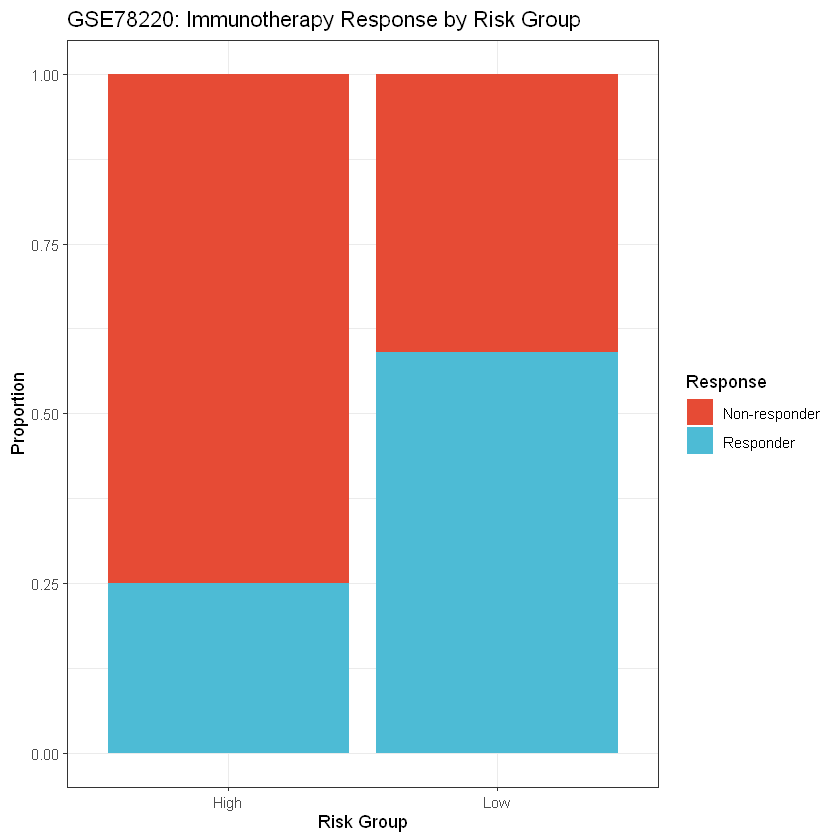

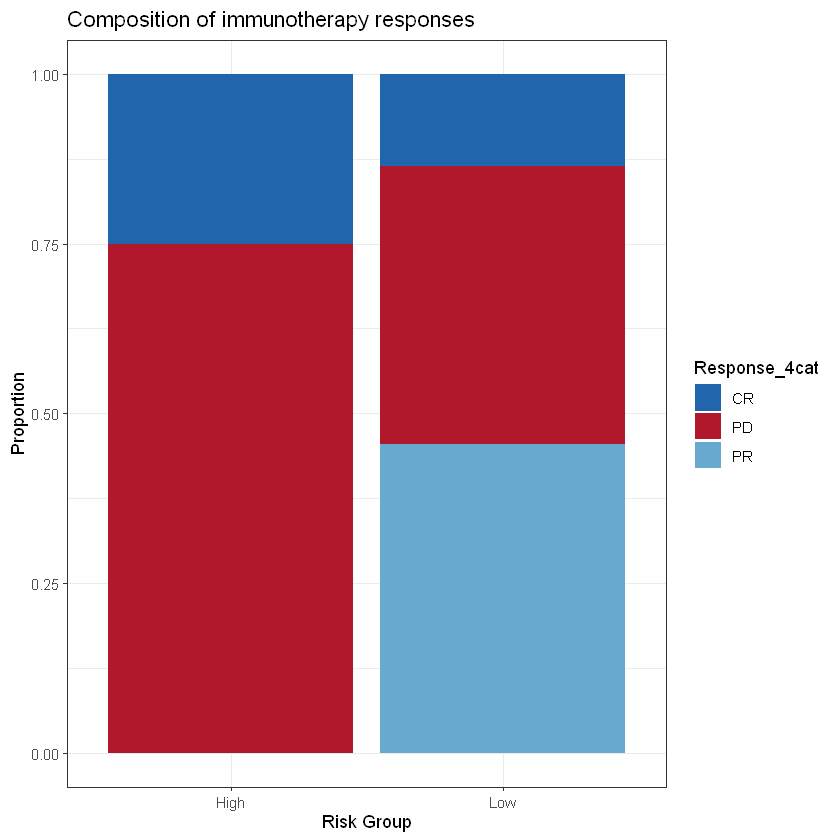

In [12]:
# 免疫治疗反应分析
# 客观反应率比较（Responder vs Non-responder）
res_table <- table(clinical_risk_df$RiskGroup, clinical_risk_df$Response)
print(res_table)

# Fisher 精确检验（样本量小时更推荐）
fisher_test <- fisher.test(res_table)
print(fisher_test)

# 堆叠比例柱状图
p_response <- ggplot(clinical_risk_df, aes(x = RiskGroup, fill = Response)) +
  geom_bar(position = "fill") +
  scale_fill_manual(values = c("Responder" = "#4DBBD5", "Non-responder" = "#E64B35")) +
  labs(x = "Risk Group", y = "Proportion", 
       title = "GSE78220: Immunotherapy Response by Risk Group") +
  theme_bw()
print(p_response)
ggsave(paste0(result_dir, "GSE78220_response_proportion.pdf"), p_response, width = 10, height = 8, dpi=300)

# CR/PR/PD
if("Response_4cat" %in% colnames(clinical_risk_df)) {
  p_4cat <- ggplot(clinical_risk_df, aes(x = RiskGroup, fill = Response_4cat)) +
    geom_bar(position = "fill") +
    scale_fill_manual(values = c("CR" = "#2166AC", "PR" = "#67A9CF", 
                                 "PD" = "#B2182B")) +
    labs(x = "Risk Group", y = "Proportion",
         title = "Composition of immunotherapy responses") +
    theme_bw()
  print(p_4cat)
  ggsave(paste0(result_dir, "GSE78220_response_4cat_proportion.pdf"), p_4cat, width = 10, height = 8, dpi=300)
}

Ignoring unknown labels:
• colour : "Risk Group"
Ignoring unknown labels:
• colour : "Risk Group"


agg_record_12ac2dea7cc0 
                      2

Log-rank p-value: 0.819984 


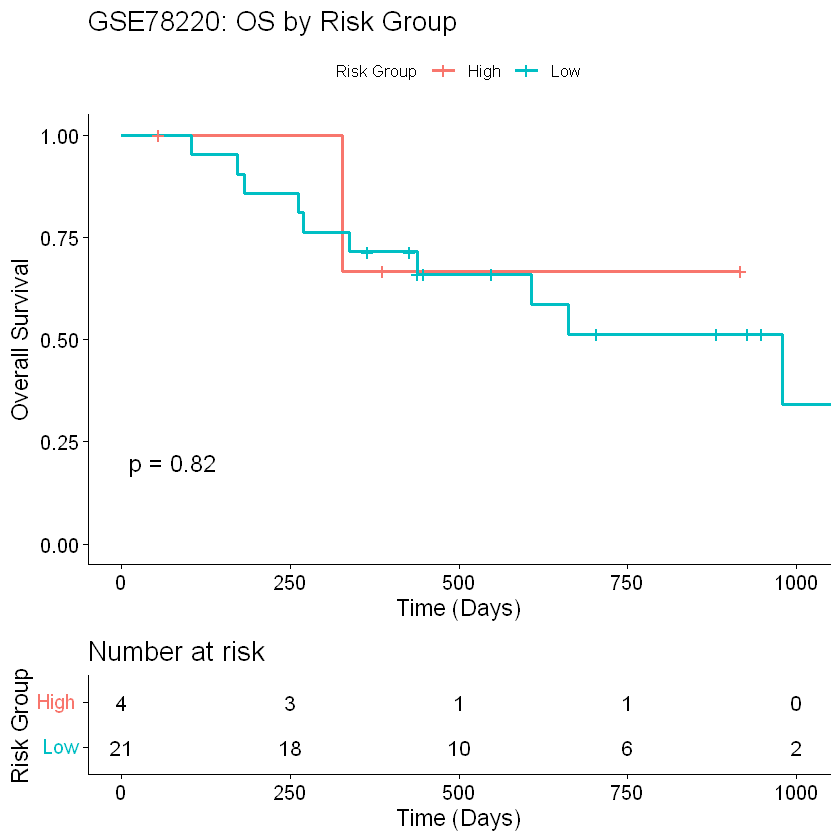

In [13]:
# KM 曲线
# 拟合 KM 曲线
clinical_df <- data.frame(
    time = clinical_risk_df$`Overall Survival`, 
    event = clinical_risk_df$OS_event,
    RiskGroup = clinical_risk_df$RiskGroup
)
fit_gse <- survfit(Surv(time, event) ~ RiskGroup, data = clinical_df)

# 绘制生存曲线
p_surv <- ggsurvplot(
  fit_gse,
  data = clinical_df,
  pval = TRUE,
  pval.coord = c(10, 0.2),          
  legend.title = "Risk Group",
  legend.labs = c("High", "Low"),
  risk.table = TRUE,
  xlab = "Time (Days)",
  ylab = "Overall Survival",
  title = "GSE78220: OS by Risk Group"
)
print(p_surv)

pdf(paste0(result_dir, "GSE78220_KM_curve.pdf"), width = 10, height = 8)
print(p_surv)
dev.off()

# 输出 log-rank 检验结果
logrank_res <- survdiff(Surv(time, event) ~ RiskGroup, data = clinical_df)
cat("Log-rank p-value:", 1 - pchisq(logrank_res$chisq, df = 1), "\n")

* 亚组分析不显著，可能是GSE78220队列样本量很少，参与分析的就26个样本（高风险组只有4个样本，统计效力极低）。故后续考虑样本量更大，数据更完整的IMvigor210队列。

#### IMvigor210

In [ ]:
# 获取IMvigor210CoreBiologies的表达数据，注释数据及表型数据(基于R 4.0.3 + Bioconductor 3.12 + DESeq 1.39.0 )
library(IMvigor210CoreBiologies)
data(cds)
expreSet <- as.data.frame(counts(cds))
annoData <- fData(cds)
phenoData <- pData(cds)
save(expreSet, annoData, phenoData, file=paste0(result_dir, "data/IMvigor210CoreBiologies/IMvigor210CoreBiologies.Rdata"))

In [14]:
# 加载保存的Rdata
load(paste0(result_dir, "data/IMvigor210CoreBiologies/IMvigor210CoreBiologies.Rdata"))

In [15]:
# expression
expMatrix <- expreSet
eff_length2 <- annoData[,c("entrez_id","length","symbol")]
rownames(eff_length2) <- eff_length2$entrez_id
head(eff_length2)
feature_ids <- rownames(expMatrix)
expMatrix <- expMatrix[feature_ids %in% rownames(eff_length2),]
mm <- match(rownames(expMatrix),rownames(eff_length2))
eff_length2 <- eff_length2[mm,]

x <- expMatrix/eff_length2$length
eset <- t(t(x)/colSums(x))*1e6 # TPM


# 基因名去重 & 标准化，一个基因对应多个探针/转录本，采用method="mean"来处理重复
summary(duplicated(rownames(eset)))
eset <- IOBR::anno_eset(eset = eset,
                        annotation = eff_length2,
                        symbol = "symbol",
                        probe = "entrez_id",
                        method = "mean")

# log2 transform
tumor_type <- "blca"
if(max(eset)>100) eset <- log2(eset+1)

,entrez_id,length,symbol
,<chr>,<int>,<chr>
1,1,1766,A1BG
10,10,1317,NAT2
100,100,3386,ADA
1000,1000,4504,CDH2
10000,10000,39468,AKT3
100008586,100008586,598,GAGE12F


   Mode   FALSE 
logical   31286 

ℹ Row number of original eset: 31286

✔ 100% of probes in expression set were annotated

ℹ Found 135 duplicate symbols, using "mean" method

ℹ Row number after filtering duplicated gene symbol: 26130



In [16]:
head(eset[1:5,1:5])

,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9,SAMf275eb859a39
SNORA73A,15.63333,16.49247,16.51928,14.54018,15.60335
RMRP,15.40357,15.45353,15.80715,15.03287,14.85152
SNORA73B,15.16934,15.29423,15.35511,13.57545,14.76089
MALAT1,13.09269,13.10093,13.71670,13.80589,14.13650
SNORD3A,12.72301,13.45434,14.94593,11.76401,13.51879


In [17]:
# phenotype
library("dplyr")
library("survival")
library("survminer")

pdata <- phenoData
colnames(pdata) <- gsub(colnames(pdata),pattern = " ",replacement = "_")
pdata <- pdata %>%
  mutate(
      Response = case_when(
          Best_Confirmed_Overall_Response %in% c("CR", "PR") ~ "Responder",
          Best_Confirmed_Overall_Response %in% c("SD", "PD") ~ "Non-responder",
          Best_Confirmed_Overall_Response == "NE" ~ NA_character_
  ),
     Response_4cat = Best_Confirmed_Overall_Response,
     status = ifelse(censOS == 0, 1, 0),
  ) %>% 
  select(Response, Response_4cat, status, os)

surv_obj <- Surv(time = pdata$os, event = pdata$status)

In [18]:
head(pdata)

,Response,Response_4cat,status,os
,<chr>,<fct>,<dbl>,<dbl>
SAMf2ce197162ce,NA,NE,0,1.5770021
SAM698d8d76b934,NA,NE,0,0.4271047
SAMc1b27bc16435,Responder,PR,1,24.1806982
SAM85e41e7f33f9,NA,NE,0,0.6242300
SAMf275eb859a39,Responder,PR,1,24.4763860
SAM7f0d9cc7f001,Non-responder,PD,0,4.6324435


In [19]:
# 按模型基因顺序提取子集并Z-score 标准化
eset_sub <- eset[model_genes, , drop = FALSE]
eset_scaled <- (eset_sub - train_params[model_genes ,"train_mean"]) / train_params[model_genes ,"train_sd"]
eset_scaled

# 计算风险评分
eset_riskscore <- colSums(eset_scaled * model_features_coef$Coef)
print(head(eset_riskscore))

# 根据训练集 cutoff 分组
eset_risk_group <- ifelse(eset_riskscore > unique(train_params[,"train_cutoff"]), "High", "Low")

eset_risk_df <- data.frame(
  `Patient ID` = names(eset_riskscore),
  RiskScore  = as.numeric(eset_riskscore),
  RiskGroup  = eset_risk_group,
  stringsAsFactors = FALSE,
  row.names = NULL,
  check.names = FALSE
)

# 合并临床信息 疗效评估：'Progressive Disease(PD)''Partial Response(PR)''Complete Response(CR)' 'Stable Disease(SD)'
pdata$`Patient ID` = rownames(pdata)
est_clinical_risk_df <- merge(pdata, eset_risk_df, by = "Patient ID")
print(head(est_clinical_risk_df))

write.table(est_clinical_risk_df, paste0(result_dir, "IMvigor210_clinical_risk_df.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9,SAMf275eb859a39,SAM7f0d9cc7f001,SAM4305ab968b90,SAMcf018fee2acd,SAMb2f1d0e54ece,SAMcc4675f394a1,⋯,SAMe7e4f7c076a7,SAMbe25e2c88f3e,SAM4caabd64e7fd,SAMc6eff056c89a,SAM5cfa1699bdb7,SAMda4d892fddc8,SAM3a1c9632ff7b,SAM8b4b8b0f9e73,SAMe3d4266775a9,SAM2de7cffb5f72
ANLN,-2.5435810,-2.1199691,-2.0351512,-1.7023072,-3.2282812,-3.2740623,-2.5955473,-3.2987862,-2.3877316,-3.4912733,⋯,-2.5134631,-1.7245048,-2.4778197,-3.3734647,-2.6462200,-3.69635142,-2.4437550,-3.9938217,-2.6254578,-2.4254753
GPD1L,-6.4555731,-6.9544727,-4.9097013,-7.7556526,-5.6713418,-6.1277239,-5.5424328,-5.0281417,-7.0207272,-7.0949022,⋯,-9.5117559,-8.9730176,-5.8624804,-7.5566490,-6.3001704,-7.36875880,-6.0288502,-6.0336031,-5.6222951,-5.1150235
CAV3,-0.6568847,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.2622563,-0.7144679,-0.3484850,-0.7144679,-0.7144679,⋯,-0.7144679,-0.7144679,-0.7144679,-0.7144679,-0.6661649,-0.71446787,-0.6467703,-0.7144679,-0.7144679,-0.7144679
ERO1L,-3.1728934,-4.1960561,-4.5443367,-3.1613478,-3.5934523,-4.7469520,-2.9734091,-4.5208211,-4.0112540,-4.8549547,⋯,-2.8165919,-4.2593830,-3.5918859,-4.6055199,-4.1384021,-4.82535420,-4.1062312,-4.0319176,-4.4245034,-4.5348070
GNG7,-5.6900359,-5.7434409,-5.6282262,-5.8166137,-5.5641124,-5.1552487,-5.8316775,-5.4788653,-5.6621289,-5.7539611,⋯,-5.8794430,-5.8794430,-5.5938912,-5.5464113,-5.7329143,-5.59560605,-5.7541419,-5.2118843,-5.7586644,-5.6090812
HMGCLL1,-2.3303337,-2.2788879,-2.3366690,-2.3646604,-2.0355146,-1.9951287,-2.3672263,-1.8908215,-2.3368676,-2.1773501,⋯,-2.3751987,-2.3751987,-2.3608750,-2.3634606,-2.3013587,-2.30991617,-2.3327744,-2.3322778,-2.1284777,-2.3172689
IRX5,-3.7562389,-3.7690572,-3.9651673,-3.4385938,-3.6965676,-3.6811121,-3.6561833,-3.1000539,-3.8837209,-3.9234189,⋯,-3.3785452,-2.3049459,-2.5985568,-3.0215669,-3.6022057,-3.96096884,-3.6135507,-3.6947633,-3.6249523,-3.6673409
ABCC2,-0.9123767,-1.1670865,-1.1561514,-1.0951547,-0.6707988,-0.8192317,-0.6576432,-0.9709867,-0.5544968,0.7397346,⋯,-1.2678002,-0.3415821,-1.0993552,-0.2391122,-0.5141711,0.07340868,-1.1372971,-1.0211823,-0.8313707,-0.7753152


SAMf2ce197162ce SAM698d8d76b934 SAMc1b27bc16435 SAM85e41e7f33f9 SAMf275eb859a39 
      0.3393799       0.3672506       0.3314398       0.4116961       0.2477061 
SAM7f0d9cc7f001 
      0.2324829 
       Patient ID      Response Response_4cat status         os RiskScore
1 SAM00b9e5c52da9          <NA>            NE      0  1.9055441 0.2333734
2 SAM0257bbbbd388 Non-responder            SD      0 15.6386037 0.2723239
3 SAM025b45c27e05 Non-responder            PD      0  8.7720739 0.2152846
4 SAM032c642382a7 Non-responder            PD      0  2.4969199 0.5559378
5 SAM04c589eb3fb3          <NA>            NE      1  0.6899384 0.2589974
6 SAM0571f17f4045 Non-responder            SD      0  4.5338809 0.2937808
  RiskGroup
1      High
2      High
3      High
4      High
5      High
6      High


In [21]:
table(est_clinical_risk_df$Response_4cat, est_clinical_risk_df$RiskGroup, useNA = "ifany")

    
     High Low
  CR   23   2
  PR   39   4
  SD   54   9
  PD  155  12
  NE   49   1

      
       Non-responder Responder
  High           209        62
  Low             21         6

	Fisher's Exact Test for Count Data

data:  est_res_table
p-value = 1
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.304401 2.610014
sample estimates:
odds ratio 
  0.963228 



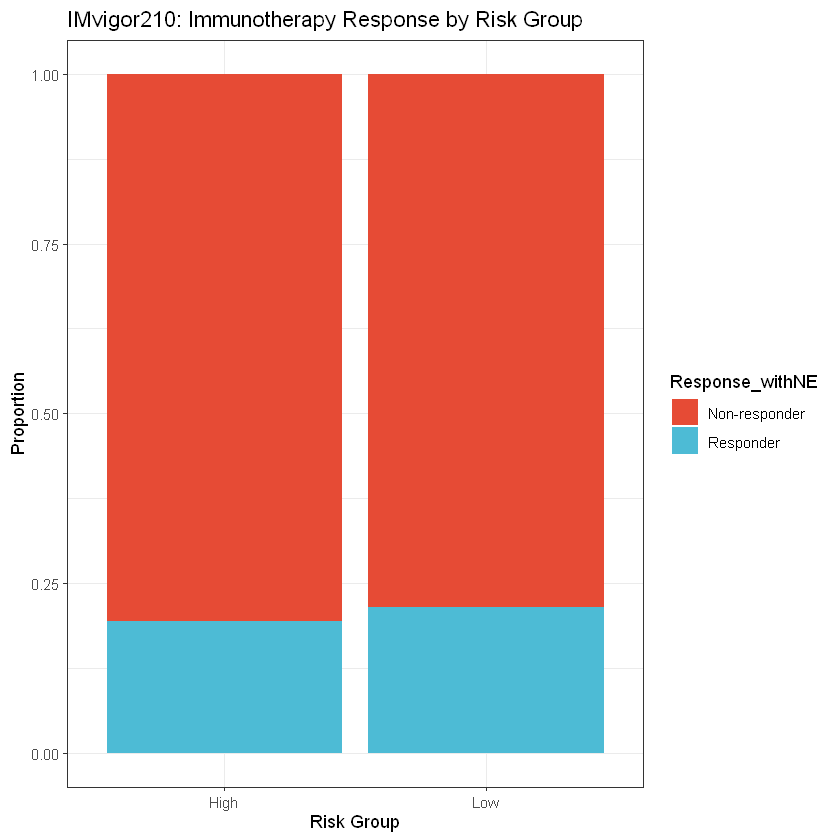

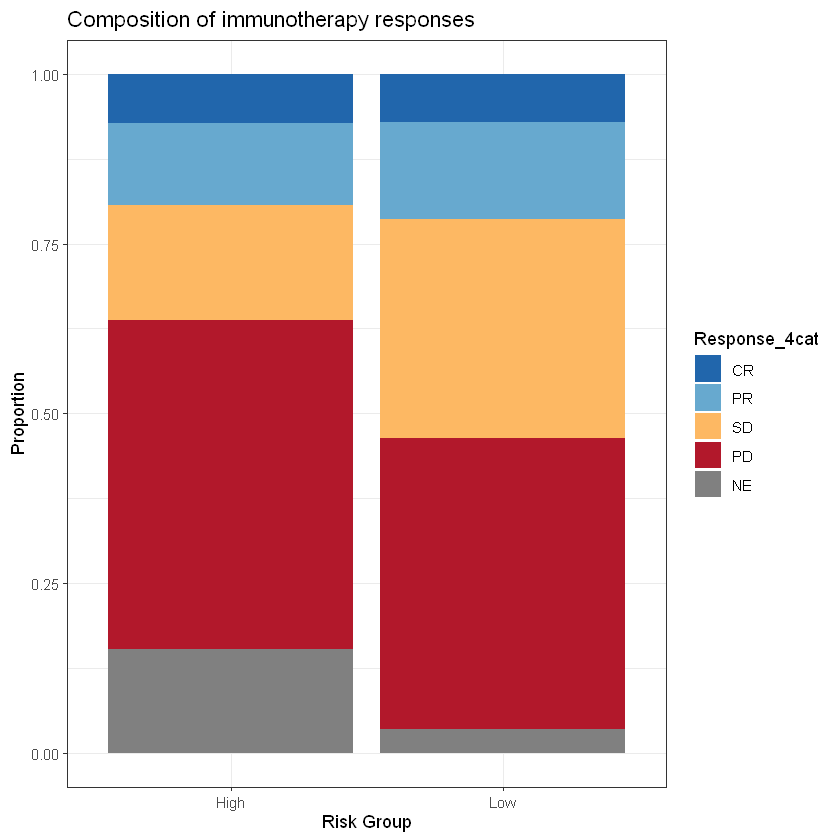

In [22]:
# 免疫治疗反应分析
# 客观反应率比较（Responder vs Non-responder）
est_res_table <- table(est_clinical_risk_df$RiskGroup, est_clinical_risk_df$Response)
print(est_res_table)

# Fisher 精确检验（样本量小时更推荐）
est_fisher_test <- fisher.test(est_res_table)
print(est_fisher_test)

# 堆叠比例柱状图
est_clinical_risk_df$Response_withNE <- est_clinical_risk_df$Response
est_clinical_risk_df$Response_withNE[est_clinical_risk_df$Response_4cat == "NE"] <- "Non-responder"

est_p_response <- ggplot(est_clinical_risk_df, aes(x = RiskGroup, fill = Response_withNE)) +
  geom_bar(position = "fill") +
  scale_fill_manual(values = c("Responder" = "#4DBBD5", "Non-responder" = "#E64B35")) +
  labs(x = "Risk Group", y = "Proportion", 
       title = "IMvigor210: Immunotherapy Response by Risk Group") +
  theme_bw()
print(est_p_response)
ggsave(paste0(result_dir, "IMvigor210_response_proportion.pdf"), est_p_response, width = 10, height = 8, dpi=300)

# CR/PR/PD
if("Response_4cat" %in% colnames(est_clinical_risk_df)) {
  est_p_4cat <- ggplot(est_clinical_risk_df, aes(x = RiskGroup, fill = Response_4cat)) +
    geom_bar(position = "fill") +
    scale_fill_manual(values = c("CR" = "#2166AC", "PR" = "#67A9CF", 
                                 "SD" = "#FDB863", "PD" = "#B2182B",
                                 "NE" = "#808080")) +
    labs(x = "Risk Group", y = "Proportion",
         title = "Composition of immunotherapy responses") +
    theme_bw()
  print(est_p_4cat)
  ggsave(paste0(result_dir, "IMvigor210_response_4cat_proportion.pdf"), est_p_4cat, width = 10, height = 8, dpi=300)
}

Ignoring unknown labels:
• colour : "Risk Group"
Ignoring unknown labels:
• colour : "Risk Group"


agg_record_12ac58faeea 
                     2

Log-rank p-value: 0.5857028 


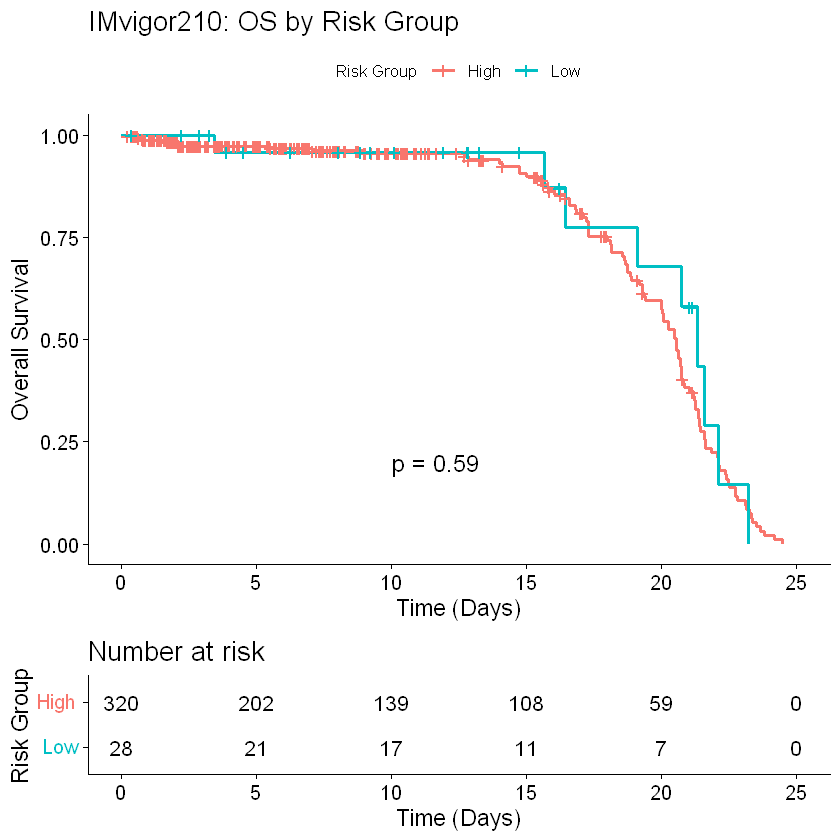

In [23]:
# KM 曲线
# 拟合 KM 曲线
est_clinical_df <- data.frame(
    time = est_clinical_risk_df$os, 
    event = est_clinical_risk_df$status,
    RiskGroup = est_clinical_risk_df$RiskGroup
)
est_fit_gse <- survfit(Surv(time, event) ~ RiskGroup, data = est_clinical_df)

# 绘制生存曲线
est_p_surv <- ggsurvplot(
  est_fit_gse,
  data = est_clinical_df,
  pval = TRUE,
  pval.coord = c(10, 0.2),          
  legend.title = "Risk Group",
  legend.labs = c("High", "Low"),
  risk.table = TRUE,
  xlab = "Time (Days)",
  ylab = "Overall Survival",
  title = "IMvigor210: OS by Risk Group"
)
print(est_p_surv)

pdf(paste0(result_dir, "IMvigor210_KM_curve.pdf"), width = 10, height = 8)
print(est_p_surv)
dev.off()

# 输出 log-rank 检验结果
est_logrank_res <- survdiff(Surv(time, event) ~ RiskGroup, data = est_clinical_df)
cat("Log-rank p-value:", 1 - pchisq(est_logrank_res$chisq, df = 1), "\n")